# Basic detection: people & two-wheelers

Uses **YOLOv8n** (COCO) with classes:

- **person** (id 0)
- **bicycle** (id 1) and **motorcycle** (id 3) as two-wheeler vehicles

Run cells top to bottom. Project root is detected automatically so paths work whether the kernel cwd is the repo root or `src/detection`.

In [38]:
from pathlib import Path
from ultralytics import YOLO

PROJECT_ROOT = Path(r"D:/Projects/CV Project")
MODEL_DIR = PROJECT_ROOT / "models"
weights = MODEL_DIR / "yolov8n.pt"

if not weights.is_file():
    raise FileNotFoundError(
        f"Expected weights at {weights}. Keep a single copy in models/."
    )

model = YOLO(str(weights))
print("Weights:", weights.resolve())

Weights: D:\Projects\CV Project\models\yolov8n.pt


In [39]:
PERSON = 0
BICYCLE = 1
MOTORCYCLE = 3
TARGET_CLASSES = [PERSON, BICYCLE, MOTORCYCLE]


COLORS = {
    PERSON: (0, 255, 0),       # green
    BICYCLE: (0, 165, 255),     # orange
    MOTORCYCLE: (255, 0, 255),  # magenta
}


def point_inside_box(
    point_xy: tuple[float, float],
    box_xyxy: tuple[float, float, float, float],
    inclusive: bool = True,
) -> bool:
    """Return True if a 2D point lies inside an XYXY box."""
    cx, cy = point_xy
    x1, y1, x2, y2 = box_xyxy

    # Normalize in case coordinates are reversed.
    left, right = sorted((x1, x2))
    top, bottom = sorted((y1, y2))

    if inclusive:
        return left <= cx <= right and top <= cy <= bottom
    return left < cx < right and top < cy < bottom


def bottom_center_inside_box(
    person_box_xyxy: tuple[float, float, float, float],
    bike_box_xyxy: tuple[float, float, float, float],
    inclusive: bool = True,
) -> bool:
    """Use rider bottom-center contact point to test bike association."""
    x1, _y1, x2, y2 = person_box_xyxy
    cx = (x1 + x2) / 2.0
    cy = y2
    return point_inside_box((cx, cy), bike_box_xyxy, inclusive=inclusive)


def draw_boxes(
    image_bgr: np.ndarray,
    results,
    names: dict,
    conf_threshold: float = 0.25,
) :
    # We draw boxes on a copy of the original image here
    out = image_bgr.copy()
    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return out

    boxes = r.boxes
    for i in range(len(boxes)):
        conf = float(boxes.conf[i])
        if conf < conf_threshold:
            continue
        cls_id = int(boxes.cls[i])
        if cls_id not in COLORS:
            continue

        x1, y1, x2, y2 = map(int, boxes.xyxy[i].tolist())
        color = COLORS[cls_id]
        label = names.get(cls_id, str(cls_id))
        caption = f"{label} {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        ty = max(y1 - 8, 20)
        cv2.putText(
            out,
            caption,
            (x1, ty),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )
    return out


def run_detection(image_path: Path, conf: float = 0.25):
    # Load image and run  YOLO on people and two wheelers
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    results = model.predict(
        source=image_bgr,
        classes=TARGET_CLASSES,
        conf=conf,
        verbose=False,
    )
    vis = draw_boxes(image_bgr, results, model.names, conf_threshold=conf)
    return image_bgr, results, vis


# Sample image
IMAGE_NAME = "4.jpg"
image_path = PROJECT_ROOT / "test_images" / IMAGE_NAME

_raw, results, vis_bgr = run_detection(image_path)

n = len(results[0].boxes) if results[0].boxes is not None else 0
print(f"Detections (filtered classes): {n}")
if n:
    for i in range(n):
        cls_id = int(results[0].boxes.cls[i])
        conf = float(results[0].boxes.conf[i])
        print(f"  - {model.names[cls_id]:12s}  conf={conf:.3f}")

    # Quick smoke test for point_inside_box using first detection.
    first_box = tuple(results[0].boxes.xyxy[0].tolist())
    x1, y1, x2, y2 = first_box
    center_point = ((x1 + x2) / 2.0, (y1 + y2) / 2.0)
    print("center point inside first box:", point_inside_box(center_point, first_box))

    # If at least one person and one bike exist, test bottom-center association.
    person_box = None
    bike_box = None
    for i in range(n):
        cls_id = int(results[0].boxes.cls[i])
        box = tuple(results[0].boxes.xyxy[i].tolist())
        if person_box is None and cls_id == PERSON:
            person_box = box
        if bike_box is None and cls_id in (BICYCLE, MOTORCYCLE):
            bike_box = box

    if person_box is not None and bike_box is not None:
        print(
            "person bottom-center inside bike box:",
            bottom_center_inside_box(person_box, bike_box),
        )

Detections (filtered classes): 2
  - person        conf=0.825
  - motorcycle    conf=0.790
center point inside first box: True


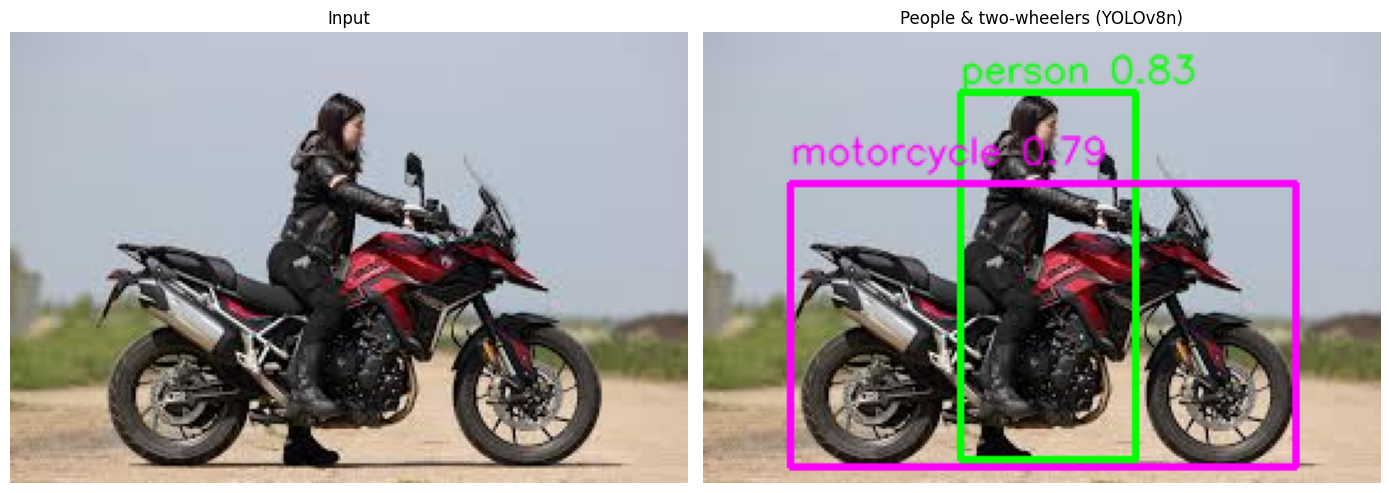

In [40]:
# We check the image
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(_raw, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("People & two-wheelers (YOLOv8n)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Notes**

- **Scooters** are often predicted as `motorcycle` with COCO-pretrained weights; for better recall you can fine-tune later.
- To save a debug image: `cv2.imwrite(str(PROJECT_ROOT / "outputs" / "det_vis.jpg"), vis_bgr)`.
- Raise or lower `conf` in `run_detection(...)` if you miss objects or get noisy boxes.